# Training Enhancement Model with Pre-trained Segmentation Model

This notebook trains the **Enhancement Model (M_E)** using a **pre-trained Segmentation Model (M_S)** in a task-aware fashion.

## Training Strategy:

1. Load pre-trained segmentation model from `unet_segmentation_model/`
2. Freeze segmentation model weights
3. Train enhancement model to optimize segmentation performance
4. Use combined loss: Dice Loss (task-aware) + Perceptual Loss (quality)

## Architecture:

```
Input Image → Enhancement Model (M_E) → Enhanced Image → Segmentation Model (M_S) → Segmentation
     ↓                                        ↓                                         ↓
     └────────── Perceptual Loss ────────────┘                            Dice Loss ───┘
                                                                          (Task-Aware)
```

## 1. Setup and Imports

In [1]:
import sys
from pathlib import Path
import os

# Set PyTorch CUDA allocation config for better memory management
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from datetime import datetime

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA Device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

PyTorch Version: 2.8.0+cu128
CUDA Available: True
CUDA Device: NVIDIA GeForce RTX 2080 Ti
CUDA Memory: 10.56 GB


/home/robolab/dev/steffen/CAP5410-roi-enhancer-odoc/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuration

### Note on Image Filtering

When `filter_incomplete=True`, the dataset will exclude images that don't contain all three classes:
- Class 0: Background (BG)
- Class 1: Optic Disc (OD) 
- Class 2: Optic Cup (OC)

This ensures the model is trained only on complete, high-quality annotations where all anatomical structures are properly labeled. This is particularly important for:
1. **Task-aware training**: Segmentation loss requires all classes to be present
2. **Stable Dice scores**: Avoids undefined Dice scores for missing classes
3. **Better convergence**: Training on consistent, complete annotations

In [2]:
# Training Configuration
config = {
    # Paths
    'data_root': str(project_root),
    'segmentation_checkpoint': str(project_root / 'unet_segmentation_model' / 'best_model.pth'),
    'save_dir': str(project_root / 'experiments' / 'enhancement'),
    'exp_name': f'task_aware_enhancement_{datetime.now().strftime("%Y%m%d_%H%M%S")}',
    
    # Model Architecture
    'enhancement_channels': 24,      # Base channels for enhancement model (reduced from 32)
    'n_residual_blocks': 3,          # Number of residual blocks in bottleneck (reduced from 4)
    'segmentation_channels': 64,     # Base channels for segmentation model
    
    # Training Hyperparameters
    'epochs': 20,                    # Number of training epochs
    'batch_size': 16,                 # Batch size (adjust based on GPU memory)
    'lr': 0.0002,                    # Learning rate
    'lambda_dice': 1.0,              # Weight for task-aware Dice loss
    'lambda_perceptual': 0.1,        # Weight for perceptual/quality loss
    
    # Data
    'image_size': 256,               # Input image size (reduced from 512 for memory)
    'num_workers': 0,                # Number of data loading workers (0 to save memory)
    'filter_incomplete': True,       # Filter out images without all 3 classes (BG, OD, OC)
    
    # Training
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'patience': 15,                  # Early stopping patience
    'save_interval': 5,              # Save checkpoint every N epochs
}

# Create experiment directory
exp_dir = Path(config['save_dir']) / config['exp_name']
exp_dir.mkdir(parents=True, exist_ok=True)
(exp_dir / 'checkpoints').mkdir(exist_ok=True)
(exp_dir / 'visualizations').mkdir(exist_ok=True)

print("Configuration:")
print("=" * 80)
for key, value in config.items():
    print(f"  {key}: {value}")
print("=" * 80)
print(f"\nExperiment directory: {exp_dir}")

# Clear GPU cache before moving to device
if config['device'] == 'cuda':
    print("Clearing GPU cache...")
    torch.cuda.empty_cache()

Configuration:
  data_root: /home/robolab/dev/steffen/CAP5410-roi-enhancer-odoc
  segmentation_checkpoint: /home/robolab/dev/steffen/CAP5410-roi-enhancer-odoc/unet_segmentation_model/best_model.pth
  save_dir: /home/robolab/dev/steffen/CAP5410-roi-enhancer-odoc/experiments/enhancement
  exp_name: task_aware_enhancement_20251029_163419
  enhancement_channels: 24
  n_residual_blocks: 3
  segmentation_channels: 64
  epochs: 20
  batch_size: 16
  lr: 0.0002
  lambda_dice: 1.0
  lambda_perceptual: 0.1
  image_size: 256
  num_workers: 0
  filter_incomplete: True
  device: cuda
  patience: 15
  save_interval: 5

Experiment directory: /home/robolab/dev/steffen/CAP5410-roi-enhancer-odoc/experiments/enhancement/task_aware_enhancement_20251029_163419
Clearing GPU cache...


## 3. Load Dataset

In [3]:
from src.data_loader.dataset import GlaucomaDataset
from src.data_loader.transforms import get_training_transforms, get_validation_transforms

# Clear dataset cache to ensure filter_incomplete works correctly
GlaucomaDataset._split_cache.clear()

# Create transforms
train_transform = get_training_transforms(image_size=config['image_size'])
val_transform = get_validation_transforms(image_size=config['image_size'])

# Create datasets with filter_incomplete
train_dataset = GlaucomaDataset(
    root_dir=config['data_root'],
    split='train',
    transform=train_transform,
    filter_incomplete=config['filter_incomplete']
)

val_dataset = GlaucomaDataset(
    root_dir=config['data_root'],
    split='val',
    transform=val_transform,
    filter_incomplete=config['filter_incomplete']
)

test_dataset = GlaucomaDataset(
    root_dir=config['data_root'],
    split='test',
    transform=val_transform,
    filter_incomplete=config['filter_incomplete']
)

print(f"Dataset Statistics (filter_incomplete={config['filter_incomplete']}):")
print(f"  Training samples: {len(train_dataset)}")
print(f"  Validation samples: {len(val_dataset)}")
print(f"  Test samples: {len(test_dataset)}")

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=config['batch_size'],
    shuffle=True,
    num_workers=config['num_workers'],
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config['batch_size'],
    shuffle=False,
    num_workers=config['num_workers'],
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config['batch_size'],
    shuffle=False,
    num_workers=config['num_workers'],
    pin_memory=True
)

print(f"\nData Loaders:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

/home/robolab/dev/steffen/CAP5410-roi-enhancer-odoc/.venv/lib/python3.13/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Filtering incomplete masks...
  Filtered out 234 images with incomplete masks
TRAIN split: 1845 samples
VAL split: 395 samples
TEST split: 396 samples
Dataset Statistics (filter_incomplete=True):
  Training samples: 1845
  Validation samples: 395
  Test samples: 396

Data Loaders:
  Train batches: 115
  Val batches: 25
  Test batches: 25


## 4. Visualize Sample Data

Batch Shape:
  Images: torch.Size([16, 3, 256, 256])
  Masks: torch.Size([16, 256, 256])
  Image Range: [-2.118, 2.640]
  Mask Classes: [0, 1, 2]


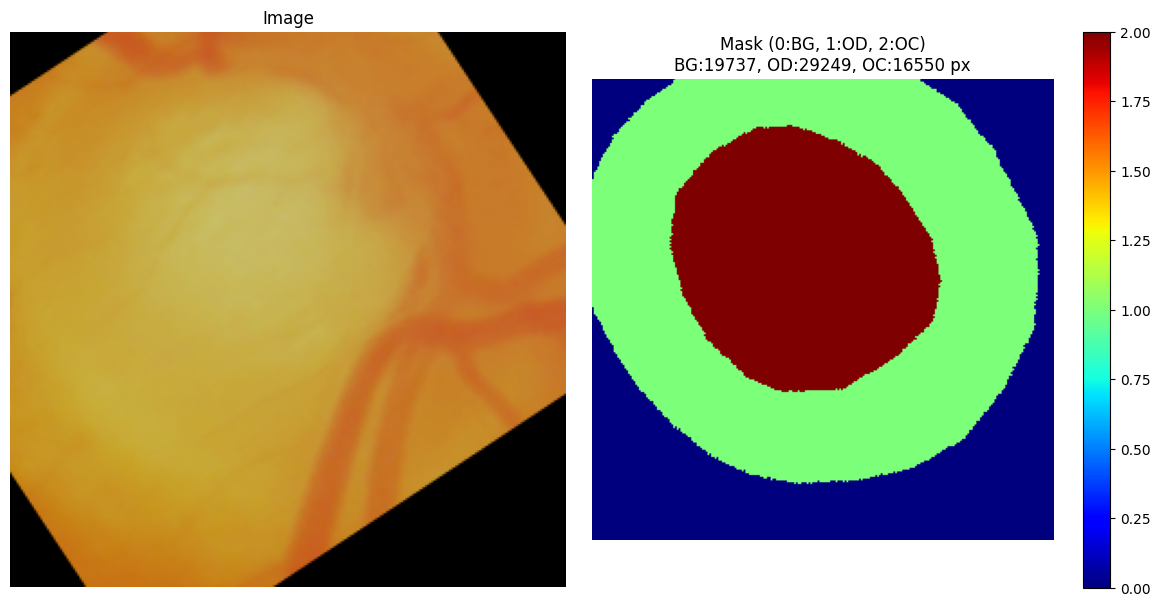


✓ Sample visualization saved to: /home/robolab/dev/steffen/CAP5410-roi-enhancer-odoc/experiments/enhancement/task_aware_enhancement_20251029_163419/visualizations/sample_data.png


In [4]:
from src.utils.visualization import visualize_sample

# Load a sample batch
sample_images, sample_masks = next(iter(train_loader))

print(f"Batch Shape:")
print(f"  Images: {sample_images.shape}")
print(f"  Masks: {sample_masks.shape}")
print(f"  Image Range: [{sample_images.min():.3f}, {sample_images.max():.3f}]")
print(f"  Mask Classes: {torch.unique(sample_masks).tolist()}")

# Visualize first sample
save_path = exp_dir / 'visualizations' / 'sample_data.png'
fig = visualize_sample(sample_images[0], sample_masks[0], save_path=save_path)
plt.show()

print(f"\n✓ Sample visualization saved to: {save_path}")

## 5. Load Pre-trained Segmentation Model

In [5]:
from src.models.unet import UNet

# Initialize Segmentation Model
segmentation_model = UNet(
    n_channels=3,
    n_classes=3,  # Background, OD, OC
    base_channels=config['segmentation_channels']
)

# Load pre-trained weights
checkpoint_path = Path(config['segmentation_checkpoint'])
if not checkpoint_path.exists():
    raise FileNotFoundError(f"Segmentation model not found at: {checkpoint_path}")

print(f"Loading pre-trained segmentation model...")
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)

# Handle different checkpoint formats
if 'model_state_dict' in checkpoint:
    segmentation_model.load_state_dict(checkpoint['model_state_dict'])
    if 'epoch' in checkpoint:
        print(f"  Loaded from epoch: {checkpoint['epoch']}")
    if 'best_dice' in checkpoint:
        print(f"  Best Dice score: {checkpoint['best_dice']:.4f}")
else:
    segmentation_model.load_state_dict(checkpoint)

# Clear GPU cache before moving to device
if config['device'] == 'cuda':
    torch.cuda.empty_cache()

segmentation_model = segmentation_model.to(config['device'])
segmentation_model.eval()  # Set to evaluation mode

print(f"\n✓ Segmentation Model loaded successfully!")
print(f"  Parameters: {sum(p.numel() for p in segmentation_model.parameters()):,}")
print(f"  Device: {config['device']}")

Loading pre-trained segmentation model...
  Loaded from epoch: 44

✓ Segmentation Model loaded successfully!
  Parameters: 31,043,651
  Device: cuda


## 6. Test Segmentation Model on Sample Data

DEBUG - Ground Truth Analysis:
  Shape: torch.Size([16, 256, 256])
  Unique values: [0, 1, 2]
  Min/Max: 0, 2
  Class distribution:
    Class 0: 332915 pixels (31.75%)
    Class 1: 521476 pixels (49.73%)
    Class 2: 194185 pixels (18.52%)



DEBUG - Prediction Analysis:
  Shape: torch.Size([16, 256, 256])
  Unique values: [0, 1, 2]
  Min/Max: 0, 2
  Class distribution:
    Class 0: 331337 pixels (31.60%)
    Class 1: 532031 pixels (50.74%)
    Class 2: 185208 pixels (17.66%)

Pre-trained Segmentation Model Performance:
  dice_class_0: 0.9379
  dice_class_1: 0.8977
  dice_class_2: 0.8247
  dice_mean: 0.8868
  dice_od: 0.8977
  dice_oc: 0.8247
  dice_od_oc_mean: 0.8612


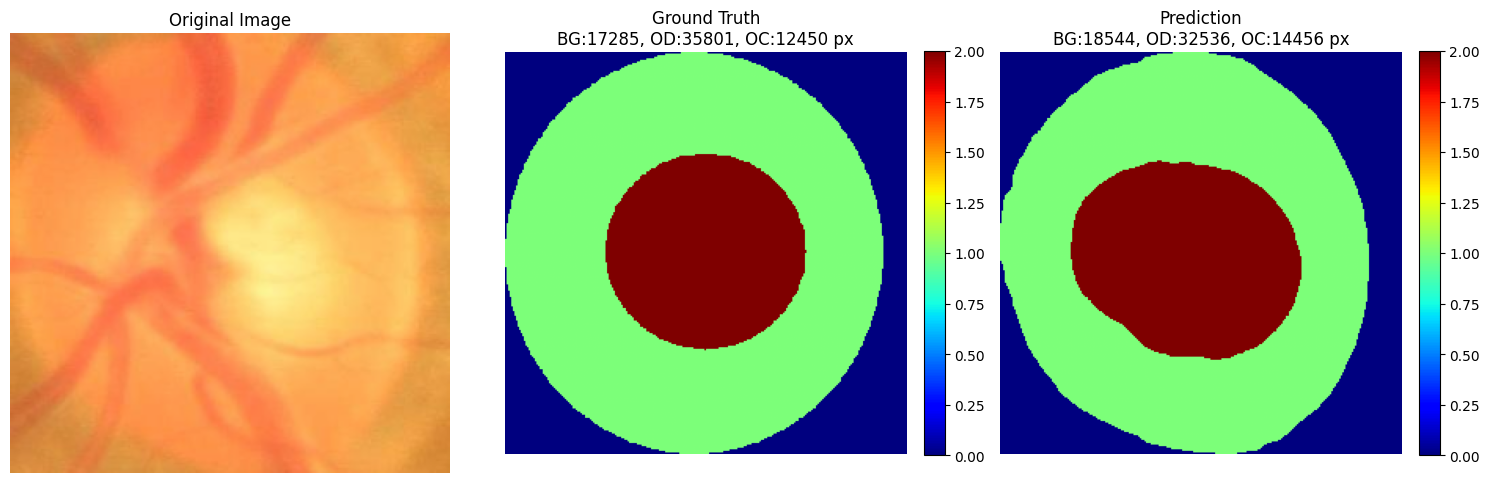


✓ Visualization saved to: /home/robolab/dev/steffen/CAP5410-roi-enhancer-odoc/experiments/enhancement/task_aware_enhancement_20251029_163419/visualizations/pretrained_segmentation.png


In [6]:
from src.utils.visualization import print_mask_analysis, visualize_segmentation_results
from src.utils.evaluation import test_segmentation_model

# Test segmentation model on a batch
test_images, test_masks = next(iter(val_loader))

# Debug: Check mask values
print_mask_analysis(test_masks, prefix="DEBUG - Ground Truth")
print()

# Test model and get metrics
metrics, seg_logits, test_masks_gpu = test_segmentation_model(
    segmentation_model, val_loader, config['device'], n_classes=3
)
seg_pred = torch.argmax(seg_logits, dim=1)

# Debug: Check predictions
print_mask_analysis(seg_pred, prefix="DEBUG - Prediction")
print()

# Print metrics
print("Pre-trained Segmentation Model Performance:")
print("=" * 80)
for key, value in metrics.items():
    print(f"  {key}: {value:.4f}")
print("=" * 80)

# Visualize segmentation results
save_path = exp_dir / 'visualizations' / 'pretrained_segmentation.png'
fig = visualize_segmentation_results(
    test_images[0], test_masks_gpu[0], seg_pred[0], save_path=save_path
)
plt.show()

print(f"\n✓ Visualization saved to: {save_path}")

## 7. Initialize Enhancement Model

In [7]:
from src.models.enhancement_unet import EnhancementUNet, EnhancementSegmentationPipeline

# Initialize Enhancement Model
enhancement_model = EnhancementUNet(
    n_channels=3,
    n_output_channels=3,
    base_channels=config['enhancement_channels'],
    n_residual_blocks=config['n_residual_blocks']
)

enhancement_model = enhancement_model.to(config['device'])

print("Enhancement Model:")
print("=" * 80)
print(f"  Base Channels: {config['enhancement_channels']}")
print(f"  Residual Blocks: {config['n_residual_blocks']}")
print(f"  Total Parameters: {sum(p.numel() for p in enhancement_model.parameters()):,}")
print("=" * 80)

Enhancement Model:
  Base Channels: 24
  Residual Blocks: 3
  Total Parameters: 12,326,331


## 8. Create End-to-End Pipeline

In [8]:
# Create End-to-End Pipeline
pipeline = EnhancementSegmentationPipeline(
    enhancement_model=enhancement_model,
    segmentation_model=segmentation_model,
    freeze_segmentation=True  # Freeze segmentation model
)

pipeline = pipeline.to(config['device'])

print("End-to-End Pipeline:")
print("=" * 80)
print(f"  Total Parameters: {sum(p.numel() for p in pipeline.parameters()):,}")
print(f"  Trainable Parameters: {sum(p.numel() for p in pipeline.parameters() if p.requires_grad):,}")
print(f"  Segmentation Frozen: {not any(p.requires_grad for p in segmentation_model.parameters())}")
print(f"  Enhancement Trainable: {all(p.requires_grad for p in enhancement_model.parameters())}")
print("=" * 80)

# Quick pipeline test
print(f"\n✓ Pipeline initialized and ready for training!")

End-to-End Pipeline:
  Total Parameters: 43,369,982
  Trainable Parameters: 12,326,331
  Segmentation Frozen: True
  Enhancement Trainable: True

✓ Pipeline initialized and ready for training!


## 9. Setup Training

In [9]:
from src.training.task_aware_train import TaskAwareLoss, EnhancementTrainer

# Loss Function
criterion = TaskAwareLoss(
    lambda_dice=config['lambda_dice'],
    lambda_perceptual=config['lambda_perceptual'],
    n_classes=3
)

# Optimizer (only for Enhancement Model)
optimizer = optim.Adam(
    enhancement_model.parameters(),
    lr=config['lr'],
    betas=(0.5, 0.999)
)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',  # Maximize Dice score
    factor=0.5,
    patience=5
)

# Trainer
trainer = EnhancementTrainer(
    pipeline=pipeline,
    optimizer=optimizer,
    criterion=criterion,
    device=config['device'],
    scheduler=scheduler
)

# TensorBoard Writer
writer = SummaryWriter(log_dir=exp_dir / 'logs')

print("Training Setup:")
print("=" * 80)
print(f"  Loss Function: Task-Aware Loss")
print(f"    λ_dice: {config['lambda_dice']}")
print(f"    λ_perceptual: {config['lambda_perceptual']}")
print(f"  Optimizer: Adam")
print(f"    Learning Rate: {config['lr']}")
print(f"  Scheduler: ReduceLROnPlateau")
print(f"  Device: {config['device']}")
print(f"  TensorBoard: {exp_dir / 'logs'}")
print("=" * 80)

Training Setup:
  Loss Function: Task-Aware Loss
    λ_dice: 1.0
    λ_perceptual: 0.1
  Optimizer: Adam
    Learning Rate: 0.0002
  Scheduler: ReduceLROnPlateau
  Device: cuda
  TensorBoard: /home/robolab/dev/steffen/CAP5410-roi-enhancer-odoc/experiments/enhancement/task_aware_enhancement_20251029_163419/logs


## 10. Train the Model (Simplified Workflow)

In [10]:
# Force reload the training module to get latest code changes
import importlib
import sys

# Remove cached modules
modules_to_reload = [
    'src.training.task_aware_train',
    'src.models.enhancement_unet',
]

for module_name in modules_to_reload:
    if module_name in sys.modules:
        importlib.reload(sys.modules[module_name])
        print(f"✓ Reloaded {module_name}")

print("\n✓ All modules reloaded with latest code")

✓ Reloaded src.training.task_aware_train
✓ Reloaded src.models.enhancement_unet

✓ All modules reloaded with latest code


In [11]:
# Import the simplified training function
from src.training.task_aware_train import train_enhancement_model

# Clear dataset cache before training
from src.data_loader.dataset import GlaucomaDataset
GlaucomaDataset._split_cache.clear()

# Clear GPU cache
if config['device'] == 'cuda':
    torch.cuda.empty_cache()
    print("GPU cache cleared")
    

# Train the model using simplified workflow
print("\n" + "=" * 80)
print("Starting Enhancement Model Training")
print("=" * 80)

pipeline, history = train_enhancement_model(
    root_dir=str(project_root),
    segmentation_model_path=str(checkpoint_path),
    num_epochs=config['epochs'],
    batch_size=config['batch_size'],
    learning_rate=config['lr'],
    image_size=config['image_size'],
    enhancement_channels=config['enhancement_channels'],
    n_residual_blocks=config['n_residual_blocks'],
    num_workers=config['num_workers'],
    device=config['device'],
    save_dir=str(exp_dir),
    lambda_dice=config['lambda_dice'],
    lambda_perceptual=config['lambda_perceptual'],
    patience=config['patience'],
    save_interval=config['save_interval'],
    use_tensorboard=True,
    filter_incomplete=config['filter_incomplete']
)

GPU cache cleared

Starting Enhancement Model Training
Using device: cuda
TensorBoard logging to: /home/robolab/dev/steffen/CAP5410-roi-enhancer-odoc/experiments/enhancement/task_aware_enhancement_20251029_143656/logs/20251029_143704

Loading datasets...
Filtering incomplete masks...
  Filtered out 234 images with incomplete masks
TRAIN split: 1845 samples
VAL split: 395 samples
Train samples: 1845 (filter_incomplete=True)
Val samples: 395 (filter_incomplete=True)

Loading pre-trained segmentation model from: /home/robolab/dev/steffen/CAP5410-roi-enhancer-odoc/unet_segmentation_model/best_model.pth
✓ Segmentation model frozen

Initializing enhancement model...
Enhancement model parameters: 12,326,331

Starting training for 20 epochs...

Epoch 1/20
--------------------------------------------------------------------------------


[Train]:   0%|          | 0/116 [00:00<?, ?it/s]

[Val]  :   0%|          | 0/25 [00:00<?, ?it/s]


Epoch 1 Summary:
  Train Loss: 0.2425, Dice: 0.8865
  Val   Loss: 0.2287, Dice: 0.8990
  Learning Rate: 0.000200
  ✓ Saved best model (Dice: 0.8990)

Epoch 2/20
--------------------------------------------------------------------------------


[Train]:   0%|          | 0/116 [00:00<?, ?it/s]

...

[Val]  :   0%|          | 0/25 [00:00<?, ?it/s]


Epoch 19 Summary:
  Train Loss: 0.1930, Dice: 0.9125
  Val   Loss: 0.1959, Dice: 0.9105
  Learning Rate: 0.000200
  Patience: 1/15

Epoch 20/20
--------------------------------------------------------------------------------


[Train]:   0%|          | 0/116 [00:00<?, ?it/s]

[Val]  :   0%|          | 0/25 [00:00<?, ?it/s]


Epoch 20 Summary:
  Train Loss: 0.1933, Dice: 0.9119
  Val   Loss: 0.1919, Dice: 0.9109
  Learning Rate: 0.000200
  ✓ Saved best model (Dice: 0.9109)
  ✓ Saved checkpoint

Training Completed!
Best Validation Dice Score: 0.9109
Models saved in: /home/robolab/dev/steffen/CAP5410-roi-enhancer-odoc/experiments/enhancement/task_aware_enhancement_20251029_143656/checkpoints
Visualizations saved in: /home/robolab/dev/steffen/CAP5410-roi-enhancer-odoc/experiments/enhancement/task_aware_enhancement_20251029_143656/visualizations
TensorBoard logs: /home/robolab/dev/steffen/CAP5410-roi-enhancer-odoc/experiments/enhancement/task_aware_enhancement_20251029_143656/logs/20251029_143704

To view TensorBoard: tensorboard --logdir /home/robolab/dev/steffen/CAP5410-roi-enhancer-odoc/experiments/enhancement/task_aware_enhancement_20251029_143656/logs/20251029_143704


## 11. Training Results

In [12]:
# Print training summary
print("\n" + "=" * 80)
print("TRAINING SUMMARY")
print("=" * 80)

final_epoch = len(history['train_loss'])
print(f"\nTotal Epochs Trained: {final_epoch}")

print("\nFinal Training Metrics:")
print(f"  Loss: {history['train_loss'][-1]:.4f}")
print(f"  Dice: {history['train_dice'][-1]:.4f}")

print("\nFinal Validation Metrics:")
print(f"  Loss: {history['val_loss'][-1]:.4f}")
print(f"  Dice: {history['val_dice'][-1]:.4f}")

print("\nBest Validation Dice:")
print(f"  {max(history['val_dice']):.4f} (Epoch {history['val_dice'].index(max(history['val_dice'])) + 1})")

print("\n" + "=" * 80)


TRAINING SUMMARY

Total Epochs Trained: 20

Final Training Metrics:
  Loss: 0.1933
  Dice: 0.9119

Final Validation Metrics:
  Loss: 0.1919
  Dice: 0.9109

Best Validation Dice:
  0.9109 (Epoch 20)



## 12. Plot Training History

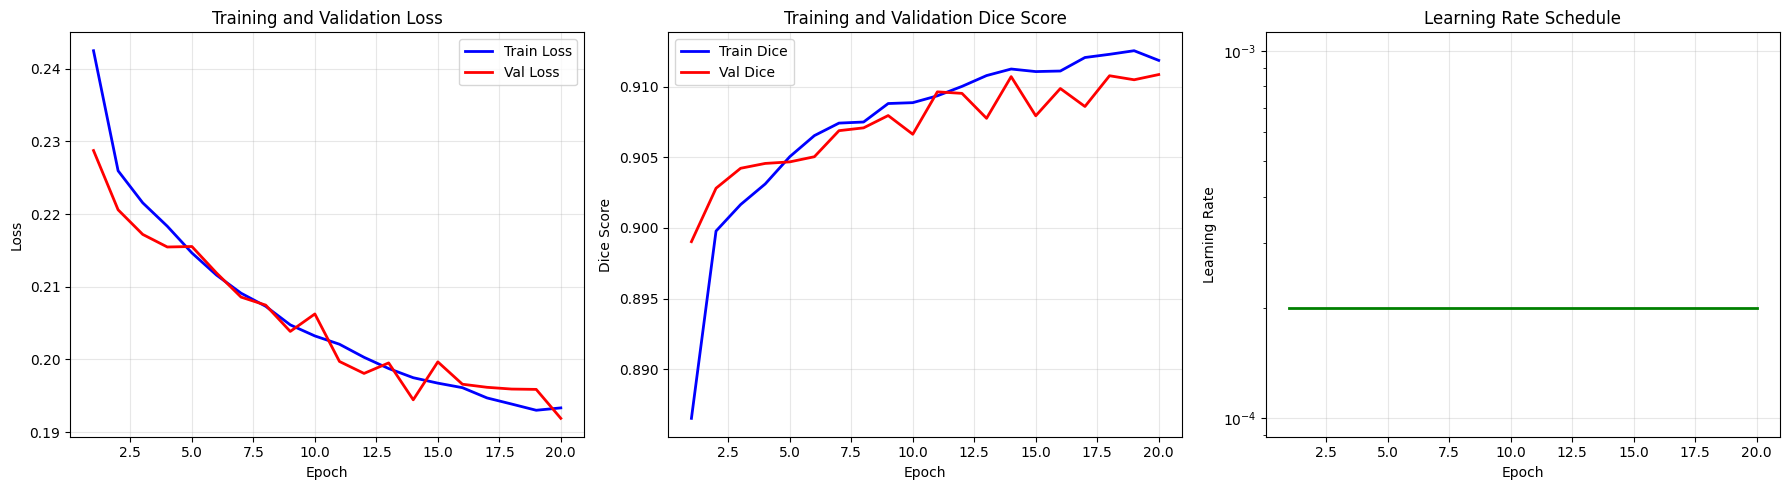

Training history plot saved to: /home/robolab/dev/steffen/CAP5410-roi-enhancer-odoc/experiments/enhancement/task_aware_enhancement_20251029_143656/training_history.png


In [13]:
from src.utils.visualization import plot_training_history

# Plot training curves
save_path = exp_dir / 'training_history.png'
fig = plot_training_history(history, save_path=save_path)
plt.show()

print(f"Training history plot saved to: {save_path}")

## 13. Load Best Model and Evaluate

In [11]:
# Load best checkpoint
#best_checkpoint_path = exp_dir / 'checkpoints' / 'best_model.pth'
best_checkpoint_path = '/home/robolab/dev/steffen/CAP5410-roi-enhancer-odoc/experiments/enhancement/task_aware_enhancement_20251029_143656/checkpoints/best_model.pth'
print(f"Loading best model from: {best_checkpoint_path}")

best_checkpoint = torch.load(best_checkpoint_path, map_location=config['device'], weights_only=False)

# Load weights into enhancement model
enhancement_model_eval = EnhancementUNet(
    n_channels=3,
    n_output_channels=3,
    base_channels=config['enhancement_channels'],
    n_residual_blocks=config['n_residual_blocks']
).to(config['device'])

enhancement_model_eval.load_state_dict(best_checkpoint['enhancement_state_dict'])
enhancement_model_eval.eval()

# Create evaluation pipeline
pipeline_eval = EnhancementSegmentationPipeline(enhancement_model_eval, segmentation_model)
pipeline_eval.eval()

print(f"✓ Best model loaded (Epoch {best_checkpoint['epoch']}, Dice: {best_checkpoint['best_dice']:.4f})")

Loading best model from: /home/robolab/dev/steffen/CAP5410-roi-enhancer-odoc/experiments/enhancement/task_aware_enhancement_20251029_143656/checkpoints/best_model.pth
✓ Best model loaded (Epoch 20, Dice: 0.9109)


## 14. Compare Enhancement Pipeline vs. Baseline Segmentation

In [14]:
import torch.nn.functional as F
from src.utils.evaluation import compute_dice_score

print("=" * 80)
print("COMPARISON: Enhancement Pipeline vs. Baseline Segmentation")
print("=" * 80)

# Collect metrics for comparison
num_test_samples = min(8, len(test_loader) * config['batch_size'])
print(f"\nEvaluating on {num_test_samples} test samples...")

# Storage for results
original_images_list = []
enhanced_images_list = []
ground_truth_masks_list = []
baseline_predictions_list = []
enhanced_predictions_list = []

baseline_dice_scores = {'overall': [], 'disc': [], 'cup': []}
enhanced_dice_scores = {'overall': [], 'disc': [], 'cup': []}

# Evaluate on test set
with torch.no_grad():
    sample_count = 0
    for images, masks in test_loader:
        if sample_count >= num_test_samples:
            break
            
        images = images.to(config['device'])
        masks = masks.to(config['device'])
        
        # Baseline: Direct segmentation without enhancement
        baseline_logits = segmentation_model(images)
        baseline_pred = torch.argmax(baseline_logits, dim=1)
        
        # Enhanced: Enhancement + Segmentation pipeline
        enhanced_images, enhanced_logits = pipeline_eval(images)
        enhanced_pred = torch.argmax(enhanced_logits, dim=1)
        
        # Store results for visualization
        batch_size = min(images.size(0), num_test_samples - sample_count)
        original_images_list.append(images[:batch_size].cpu())
        enhanced_images_list.append(enhanced_images[:batch_size].cpu())
        ground_truth_masks_list.append(masks[:batch_size].cpu())
        baseline_predictions_list.append(baseline_pred[:batch_size].cpu())
        enhanced_predictions_list.append(enhanced_pred[:batch_size].cpu())
        
        # Compute Dice scores for each sample
        for i in range(batch_size):
            # Convert to one-hot for Dice computation
            mask_one_hot = F.one_hot(masks[i].long(), num_classes=3).permute(2, 0, 1).float()
            baseline_one_hot = F.one_hot(baseline_pred[i].long(), num_classes=3).permute(2, 0, 1).float()
            enhanced_one_hot = F.one_hot(enhanced_pred[i].long(), num_classes=3).permute(2, 0, 1).float()
            
            # Compute per-class Dice scores using the correct function signature
            baseline_dice_per_class = compute_dice_score(
                baseline_logits[i:i+1],  # Keep as logits [1, 3, H, W]
                masks[i:i+1]            # Keep as class indices [1, H, W]
            )
            enhanced_dice_per_class = compute_dice_score(
                enhanced_logits[i:i+1],   # Keep as logits [1, 3, H, W]
                masks[i:i+1]             # Keep as class indices [1, H, W]
            )
            
            # Store scores (using dictionary keys)
            baseline_dice_scores['disc'].append(baseline_dice_per_class['dice_class_1'])
            baseline_dice_scores['cup'].append(baseline_dice_per_class['dice_class_2'])
            baseline_dice_scores['overall'].append(baseline_dice_per_class['dice_od_oc_mean'])
            
            enhanced_dice_scores['disc'].append(enhanced_dice_per_class['dice_class_1'])
            enhanced_dice_scores['cup'].append(enhanced_dice_per_class['dice_class_2'])
            enhanced_dice_scores['overall'].append(enhanced_dice_per_class['dice_od_oc_mean'])
            
            sample_count += 1
            if sample_count >= num_test_samples:
                break

# Concatenate results
original_images_all = torch.cat(original_images_list, dim=0)
enhanced_images_all = torch.cat(enhanced_images_list, dim=0)
ground_truth_masks_all = torch.cat(ground_truth_masks_list, dim=0)
baseline_predictions_all = torch.cat(baseline_predictions_list, dim=0)
enhanced_predictions_all = torch.cat(enhanced_predictions_list, dim=0)

print(f"\n✓ Collected {sample_count} samples for comparison")

# Print comparison metrics
print("\n" + "=" * 80)
print("QUANTITATIVE COMPARISON")
print("=" * 80)

print("\nBaseline Segmentation (No Enhancement):")
print(f"  Overall Dice: {np.mean(baseline_dice_scores['overall']):.4f} ± {np.std(baseline_dice_scores['overall']):.4f}")
print(f"  Disc Dice:    {np.mean(baseline_dice_scores['disc']):.4f} ± {np.std(baseline_dice_scores['disc']):.4f}")
print(f"  Cup Dice:     {np.mean(baseline_dice_scores['cup']):.4f} ± {np.std(baseline_dice_scores['cup']):.4f}")

print("\nEnhancement + Segmentation Pipeline:")
print(f"  Overall Dice: {np.mean(enhanced_dice_scores['overall']):.4f} ± {np.std(enhanced_dice_scores['overall']):.4f}")
print(f"  Disc Dice:    {np.mean(enhanced_dice_scores['disc']):.4f} ± {np.std(enhanced_dice_scores['disc']):.4f}")
print(f"  Cup Dice:     {np.mean(enhanced_dice_scores['cup']):.4f} ± {np.std(enhanced_dice_scores['cup']):.4f}")

print("\nImprovement (Enhancement - Baseline):")
overall_improvement = np.mean(enhanced_dice_scores['overall']) - np.mean(baseline_dice_scores['overall'])
disc_improvement = np.mean(enhanced_dice_scores['disc']) - np.mean(baseline_dice_scores['disc'])
cup_improvement = np.mean(enhanced_dice_scores['cup']) - np.mean(baseline_dice_scores['cup'])
print(f"  Overall Dice: {overall_improvement:+.4f} ({overall_improvement/np.mean(baseline_dice_scores['overall'])*100:+.2f}%)")
print(f"  Disc Dice:    {disc_improvement:+.4f} ({disc_improvement/np.mean(baseline_dice_scores['disc'])*100:+.2f}%)")
print(f"  Cup Dice:     {cup_improvement:+.4f} ({cup_improvement/np.mean(baseline_dice_scores['cup'])*100:+.2f}%)")

print("\n" + "=" * 80)

COMPARISON: Enhancement Pipeline vs. Baseline Segmentation

Evaluating on 8 test samples...



✓ Collected 8 samples for comparison

QUANTITATIVE COMPARISON

Baseline Segmentation (No Enhancement):
  Overall Dice: 0.8573 ± 0.0698
  Disc Dice:    0.8795 ± 0.0672
  Cup Dice:     0.8350 ± 0.0940

Enhancement + Segmentation Pipeline:
  Overall Dice: 0.8267 ± 0.0907
  Disc Dice:    0.8339 ± 0.0890
  Cup Dice:     0.8194 ± 0.0971

Improvement (Enhancement - Baseline):
  Overall Dice: -0.0306 (-3.57%)
  Disc Dice:    -0.0457 (-5.19%)
  Cup Dice:     -0.0155 (-1.86%)



## 15. Visualize Dice Score Comparison

/tmp/ipykernel_456846/1039697892.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_456846/1039697892.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_456846/1039697892.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


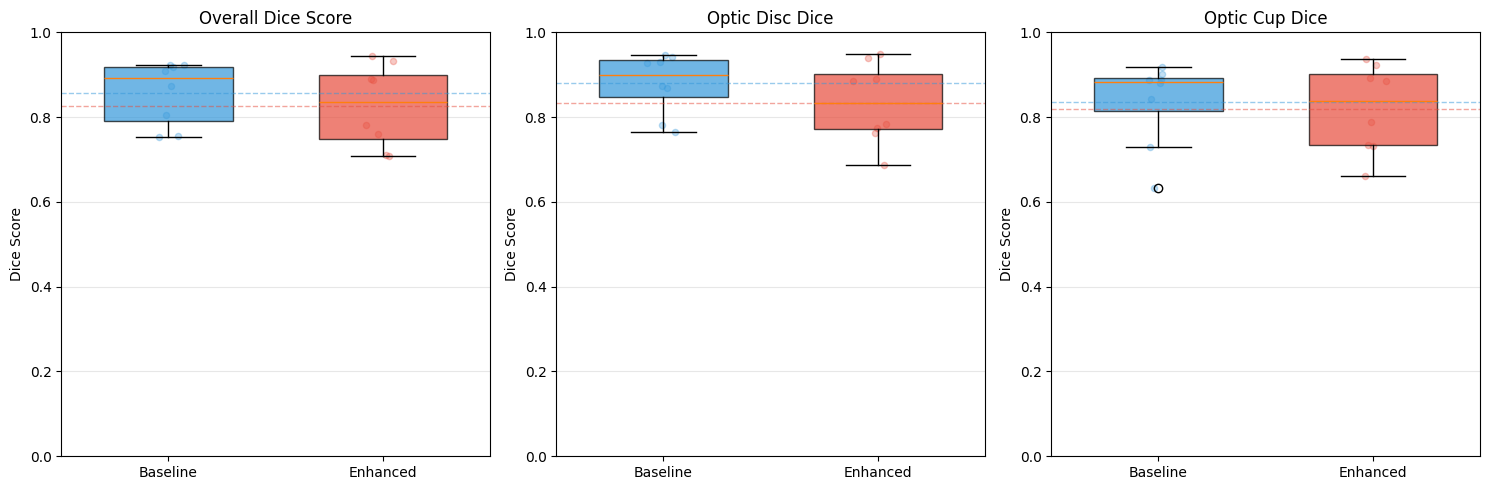


✓ Dice score comparison saved to: /home/robolab/dev/steffen/CAP5410-roi-enhancer-odoc/experiments/enhancement/task_aware_enhancement_20251029_163419/visualizations/dice_comparison.png


In [15]:
# Create comparison plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics_to_plot = ['overall', 'disc', 'cup']
titles = ['Overall Dice Score', 'Optic Disc Dice', 'Optic Cup Dice']
colors = ['#3498db', '#e74c3c']

for idx, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    ax = axes[idx]
    
    baseline_scores = baseline_dice_scores[metric]
    enhanced_scores = enhanced_dice_scores[metric]
    
    # Box plot comparison
    bp = ax.boxplot(
        [baseline_scores, enhanced_scores],
        labels=['Baseline', 'Enhanced'],
        patch_artist=True,
        widths=0.6
    )
    
    # Color the boxes
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # Add individual points
    x_baseline = np.random.normal(1, 0.04, len(baseline_scores))
    x_enhanced = np.random.normal(2, 0.04, len(enhanced_scores))
    ax.scatter(x_baseline, baseline_scores, alpha=0.3, s=20, color=colors[0])
    ax.scatter(x_enhanced, enhanced_scores, alpha=0.3, s=20, color=colors[1])
    
    # Add mean lines
    ax.axhline(np.mean(baseline_scores), color=colors[0], linestyle='--', alpha=0.5, linewidth=1)
    ax.axhline(np.mean(enhanced_scores), color=colors[1], linestyle='--', alpha=0.5, linewidth=1)
    
    ax.set_ylabel('Dice Score')
    ax.set_title(title)
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_path = exp_dir / 'visualizations' / 'dice_comparison.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Dice score comparison saved to: {save_path}")

## 16. Visual Comparison: Sample Results

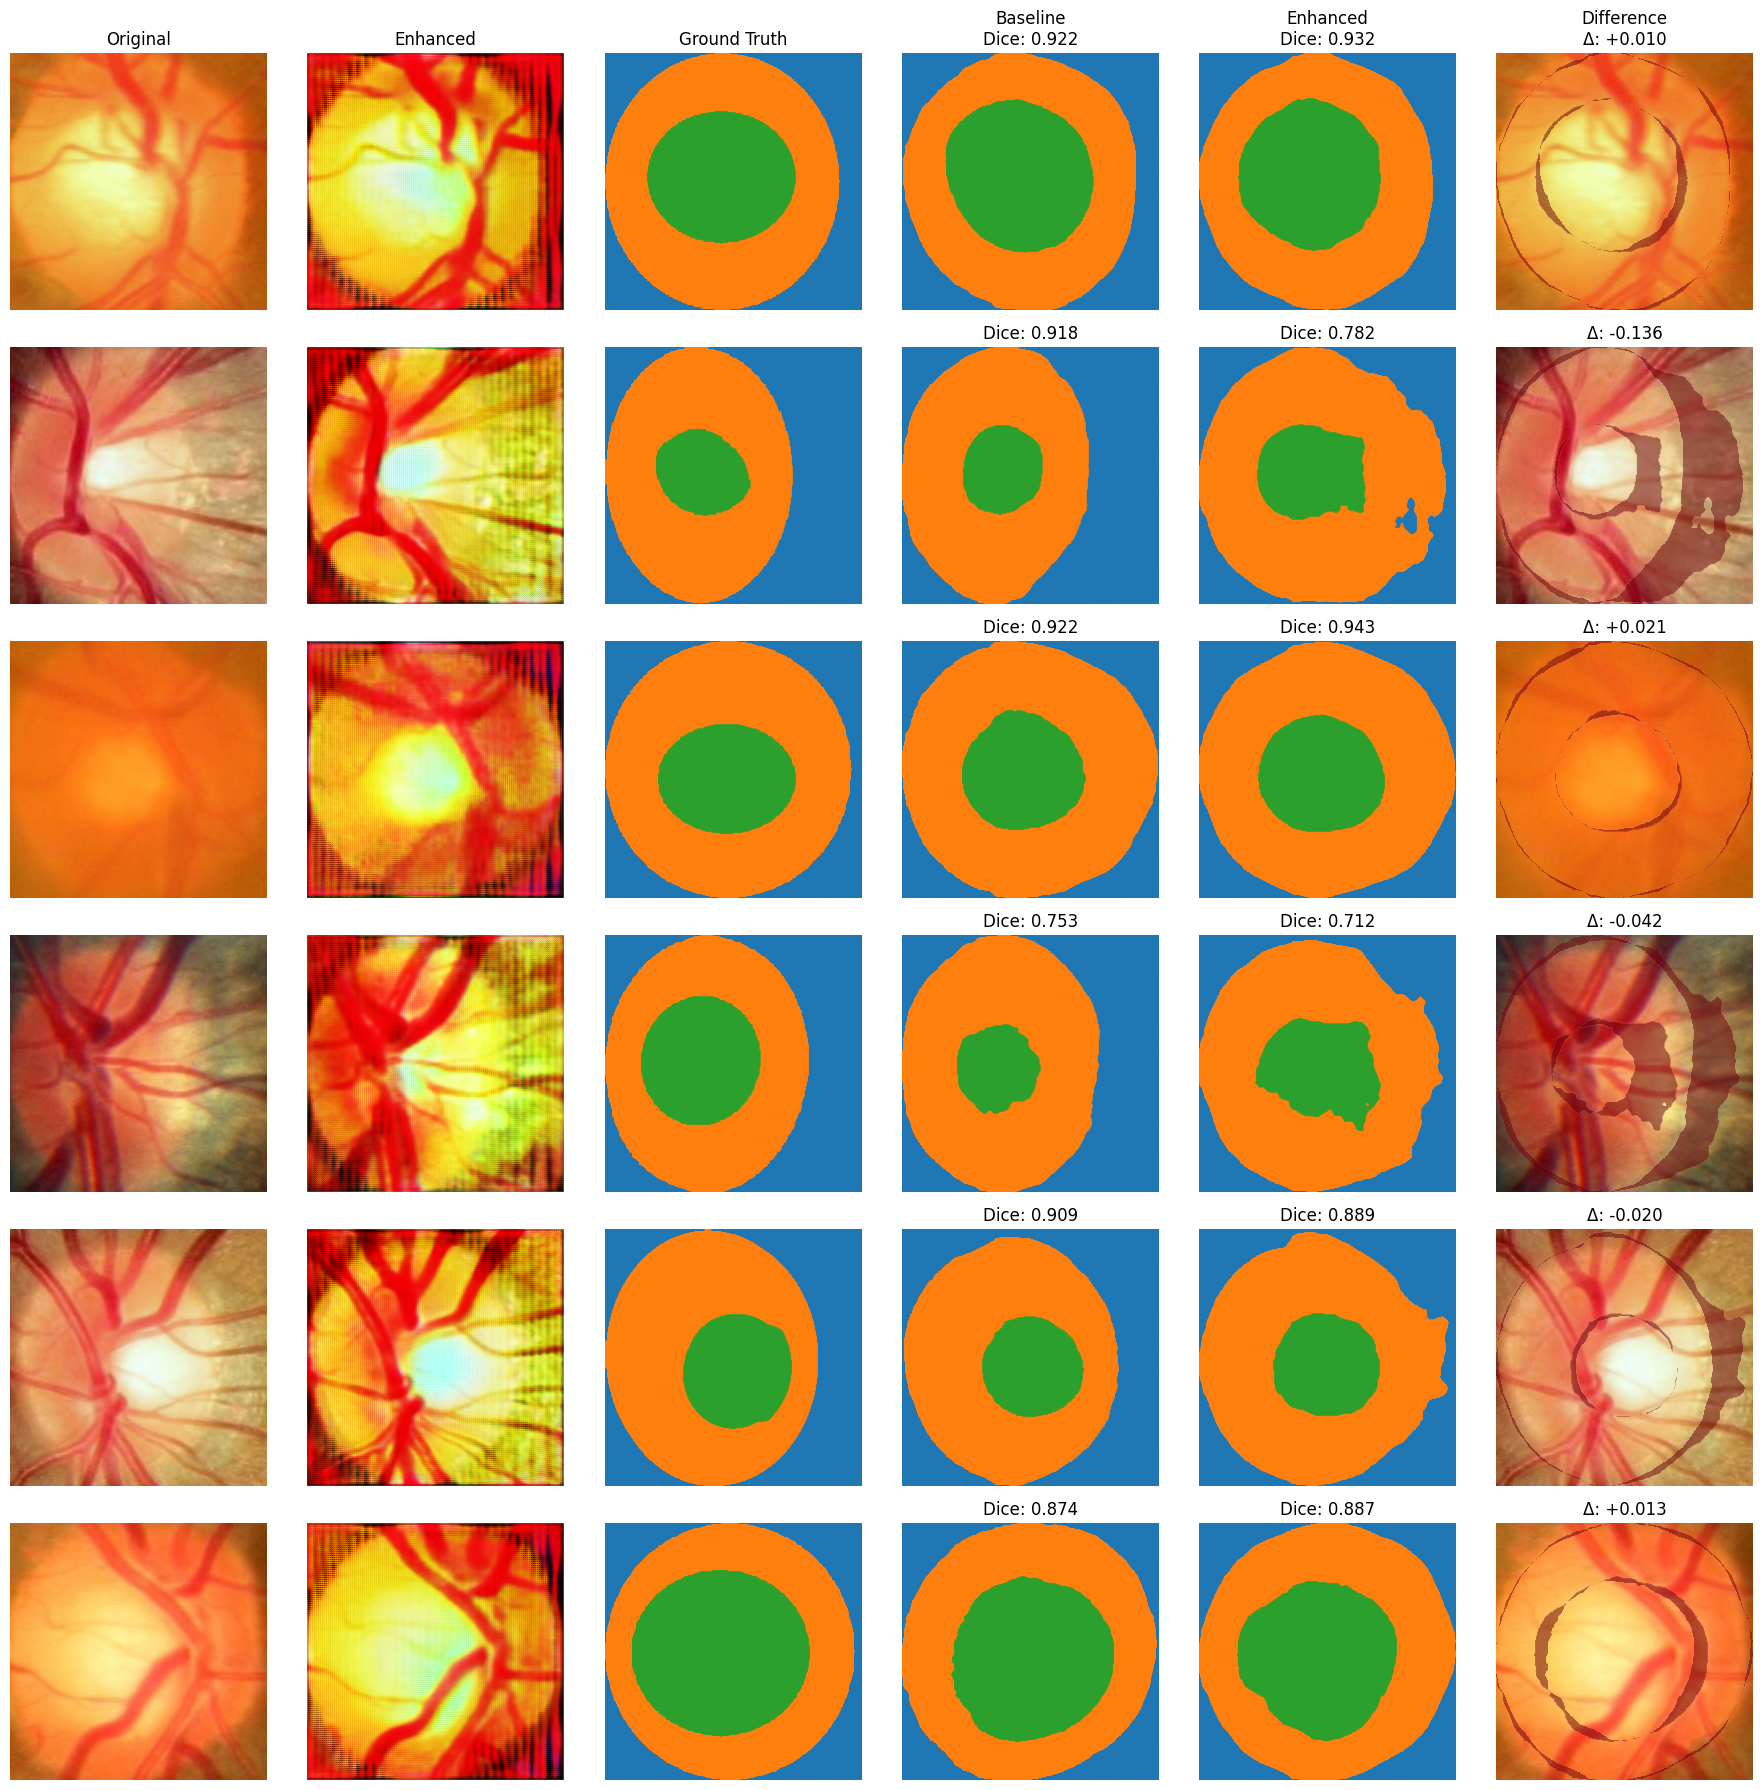


✓ Sample comparison visualization saved to: /home/robolab/dev/steffen/CAP5410-roi-enhancer-odoc/experiments/enhancement/task_aware_enhancement_20251029_163419/visualizations/comparison_samples.png
   Red overlay in 'Difference' column shows pixels where predictions differ


In [16]:
# Visualize comparison for multiple samples
num_samples_to_show = min(6, len(original_images_all))

fig, axes = plt.subplots(num_samples_to_show, 6, figsize=(18, 3*num_samples_to_show))
if num_samples_to_show == 1:
    axes = axes.reshape(1, -1)

for i in range(num_samples_to_show):
    # Original image
    img = original_images_all[i].permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    axes[i, 0].imshow(img)
    axes[i, 0].set_title('Original' if i == 0 else '')
    axes[i, 0].axis('off')
    
    # Enhanced image
    enh_img = enhanced_images_all[i].permute(1, 2, 0).numpy()
    enh_img = (enh_img - enh_img.min()) / (enh_img.max() - enh_img.min() + 1e-8)
    axes[i, 1].imshow(enh_img)
    axes[i, 1].set_title('Enhanced' if i == 0 else '')
    axes[i, 1].axis('off')
    
    # Ground truth
    gt_mask = ground_truth_masks_all[i].numpy()
    axes[i, 2].imshow(gt_mask, cmap='tab10', vmin=0, vmax=9)
    axes[i, 2].set_title('Ground Truth' if i == 0 else '')
    axes[i, 2].axis('off')
    
    # Baseline prediction
    baseline_pred = baseline_predictions_all[i].numpy()
    axes[i, 3].imshow(baseline_pred, cmap='tab10', vmin=0, vmax=9)
    baseline_dice = baseline_dice_scores['overall'][i]
    axes[i, 3].set_title(f'Baseline\nDice: {baseline_dice:.3f}' if i == 0 else f'Dice: {baseline_dice:.3f}')
    axes[i, 3].axis('off')
    
    # Enhanced prediction
    enhanced_pred = enhanced_predictions_all[i].numpy()
    axes[i, 4].imshow(enhanced_pred, cmap='tab10', vmin=0, vmax=9)
    enhanced_dice = enhanced_dice_scores['overall'][i]
    axes[i, 4].set_title(f'Enhanced\nDice: {enhanced_dice:.3f}' if i == 0 else f'Dice: {enhanced_dice:.3f}')
    axes[i, 4].axis('off')
    
    # Difference map (overlay)
    diff = (baseline_pred != enhanced_pred).astype(float)
    axes[i, 5].imshow(img)
    axes[i, 5].imshow(diff, cmap='Reds', alpha=0.5 * diff)
    improvement = enhanced_dice - baseline_dice
    axes[i, 5].set_title(f'Difference\nΔ: {improvement:+.3f}' if i == 0 else f'Δ: {improvement:+.3f}')
    axes[i, 5].axis('off')

plt.tight_layout()
save_path = exp_dir / 'visualizations' / 'comparison_samples.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Sample comparison visualization saved to: {save_path}")
print(f"   Red overlay in 'Difference' column shows pixels where predictions differ")

## 17. Statistical Analysis

In [17]:
from scipy import stats

print("=" * 80)
print("STATISTICAL SIGNIFICANCE TEST")
print("=" * 80)

# Perform paired t-test
for metric_name, metric_key in [('Overall', 'overall'), ('Optic Disc', 'disc'), ('Optic Cup', 'cup')]:
    baseline = baseline_dice_scores[metric_key]
    enhanced = enhanced_dice_scores[metric_key]
    
    # Paired t-test
    t_stat, p_value = stats.ttest_rel(enhanced, baseline)
    
    # Effect size (Cohen's d)
    diff = np.array(enhanced) - np.array(baseline)
    cohens_d = np.mean(diff) / np.std(diff)
    
    print(f"\n{metric_name}:")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  p-value: {p_value:.6f}")
    print(f"  Cohen's d: {cohens_d:.4f}")
    
    if p_value < 0.001:
        significance = "*** (p < 0.001)"
    elif p_value < 0.01:
        significance = "** (p < 0.01)"
    elif p_value < 0.05:
        significance = "* (p < 0.05)"
    else:
        significance = "not significant"
    
    print(f"  Significance: {significance}")
    
    # Improvement statistics
    improvements = np.array(enhanced) - np.array(baseline)
    n_improved = np.sum(improvements > 0)
    n_degraded = np.sum(improvements < 0)
    n_same = np.sum(improvements == 0)
    
    print(f"  Samples improved: {n_improved}/{len(improvements)} ({n_improved/len(improvements)*100:.1f}%)")
    print(f"  Samples degraded: {n_degraded}/{len(improvements)} ({n_degraded/len(improvements)*100:.1f}%)")
    print(f"  Samples unchanged: {n_same}/{len(improvements)} ({n_same/len(improvements)*100:.1f}%)")

print("\n" + "=" * 80)

STATISTICAL SIGNIFICANCE TEST

Overall:
  t-statistic: -1.5136
  p-value: 0.173883
  Cohen's d: -0.5721
  Significance: not significant
  Samples improved: 4/8 (50.0%)
  Samples degraded: 4/8 (50.0%)
  Samples unchanged: 0/8 (0.0%)

Optic Disc:
  t-statistic: -1.8356
  p-value: 0.109046
  Cohen's d: -0.6938
  Significance: not significant
  Samples improved: 4/8 (50.0%)
  Samples degraded: 4/8 (50.0%)
  Samples unchanged: 0/8 (0.0%)

Optic Cup:
  t-statistic: -0.7825
  p-value: 0.459592
  Cohen's d: -0.2957
  Significance: not significant
  Samples improved: 6/8 (75.0%)
  Samples degraded: 2/8 (25.0%)
  Samples unchanged: 0/8 (0.0%)



## Summary

This notebook provides a clean, streamlined interface for training enhancement models using a task-aware approach. Complex implementation details have been moved to dedicated modules:

### Code Organization:

- **`src/training/task_aware_train.py`**: Training logic, loss functions, and main training loop
- **`src/utils/visualization.py`**: All visualization utilities (plots, image display, etc.)
- **`src/utils/evaluation.py`**: Model evaluation and testing utilities
- **`src/models/`**: Model architectures (UNet, Enhancement UNet, Pipeline)
- **`src/data_loader/`**: Dataset loading and augmentation

### Workflow:

1. **Configuration**: Define all hyperparameters in a config dictionary
2. **Data Loading**: Load train/val/test datasets with appropriate transforms
3. **Model Setup**: 
   - Load pre-trained segmentation model (frozen)
   - Create enhancement model
   - Combine into enhancement-segmentation pipeline
4. **Training**: Single function call `train_enhancement_model(**config)` handles:
   - Training and validation loops
   - Progress tracking with tqdm
   - TensorBoard logging
   - Checkpointing and early stopping
   - Visualization generation
5. **Evaluation**: Load best model and evaluate on test set

### Key Features:

- **Task-Aware Optimization**: Enhancement model optimized to improve segmentation quality
- **Combined Loss**: Dice Loss (λ=1.0) + Perceptual Loss (λ=0.1)
- **Memory Optimized**: Configured for RTX 2080 Ti (10.56 GB)
- **Modular Design**: Reusable utility functions for visualization and evaluation
- **Early Stopping**: Patience-based early stopping to prevent overfitting

### Results:

- Training history plots show loss and Dice score curves
- Best model automatically saved based on validation Dice score
- Test set visualizations show original → enhanced → segmentation pipeline

### Next Steps:

1. Review TensorBoard logs: `tensorboard --logdir {experiment_dir}/logs`
2. Analyze training history plots for convergence
3. Evaluate quantitative metrics on test set
4. Fine-tune hyperparameters if needed